# [LAB-11] 시계열 분석 6. ARIMA 진단 및 평가

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


## 📚 도시가스 수요예측 담당자의 모형 검증

### 당신은 서울도시가스의 수요예측 담당자로 배치되었습니다.

겨울 난방 수요는 기온이 1℃ 내려갈 때마다 눈에 띄게 뛰기 때문에, 팀은 50년치 서울 월평균 기온을 모아 계절형 예측 모형을 하나 세워 두었습니다.

다음 주 임원 보고에서 당신은 이 모형으로 다음 겨울 기온을 내다보고 공급 계획을 세우겠다고 발표할 예정입니다. 그런데 팀장이 묻습니다. "그 모형, 믿고 써도 되는 건 맞아요?"

발표 전에 이 모형이 세워 둔 가정을 지키고 있는지 진단하고, 성능이 얼마나 되는지 숫자로 정리하세요.

### 💻 코드 작성

#### 데이터 가져오기

In [17]:
origin = load_data('temperatures_seoul')
df = my_ts.set_index(origin, "날짜", freq="MS")

print(f"관측 기간: {df.index[0]:%Y-%m} ~ {df.index[-1]:%Y-%m}")
print(f"관측치 개수: {len(df)}")

df.head()

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)
관측 기간: 1973-07 ~ 2023-08
관측치 개수: 602


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323
1973-10-01,13.039
1973-11-01,4.723


#### 모형 적합

In [18]:
# 팀이 확정해 둔 차수를 그대로 재현한다.
p, d, q = (1, 0, 1)
P, D, Q, s = (0, 1, 1, 12)

# 기온은 음수가 될 수 있으므로 로그변환을 쓰지 않는다
fit = my_ts.fit_model(df, "평균기온(℃)", log=False,
                      p=p, d=d, q=q, P=P, D=D, Q=Q, s=s)

시도한 조합 8가지 | 적합 성공 8가지
AIC 최적: (1,0,1)(0,1,1,12)  |  BIC 최적: (1,0,1)(0,1,1,12)


,모형,p,d,q,P,D,Q,s,계수 수,AIC,BIC
순위,,,,,,,,,,,
1,"(1,0,1)(0,1,1,12)",1,0,1,0,1,1,12,4,2060.042,2077.562
2,"(1,0,0)(0,1,1,12)",1,0,0,0,1,1,12,3,2067.928,2081.068
3,"(0,0,1)(0,1,1,12)",0,0,1,0,1,1,12,3,2078.552,2091.692
4,"(0,0,0)(0,1,1,12)",0,0,0,0,1,1,12,2,2117.377,2126.138
5,"(1,0,1)(0,1,0,12)",1,0,1,0,1,0,12,3,2395.827,2408.967
6,"(1,0,0)(0,1,0,12)",1,0,0,0,1,0,12,2,2398.706,2407.466
7,"(0,0,1)(0,1,0,12)",0,0,1,0,1,0,12,2,2401.571,2410.332
8,"(0,0,0)(0,1,0,12)",0,0,0,0,1,0,12,1,2421.290,2425.670


#### 잔차 진단

진단 대상 590개 (앞 12개 제외) | 유의수준 0.05
실패한 검정: Jarque-Bera


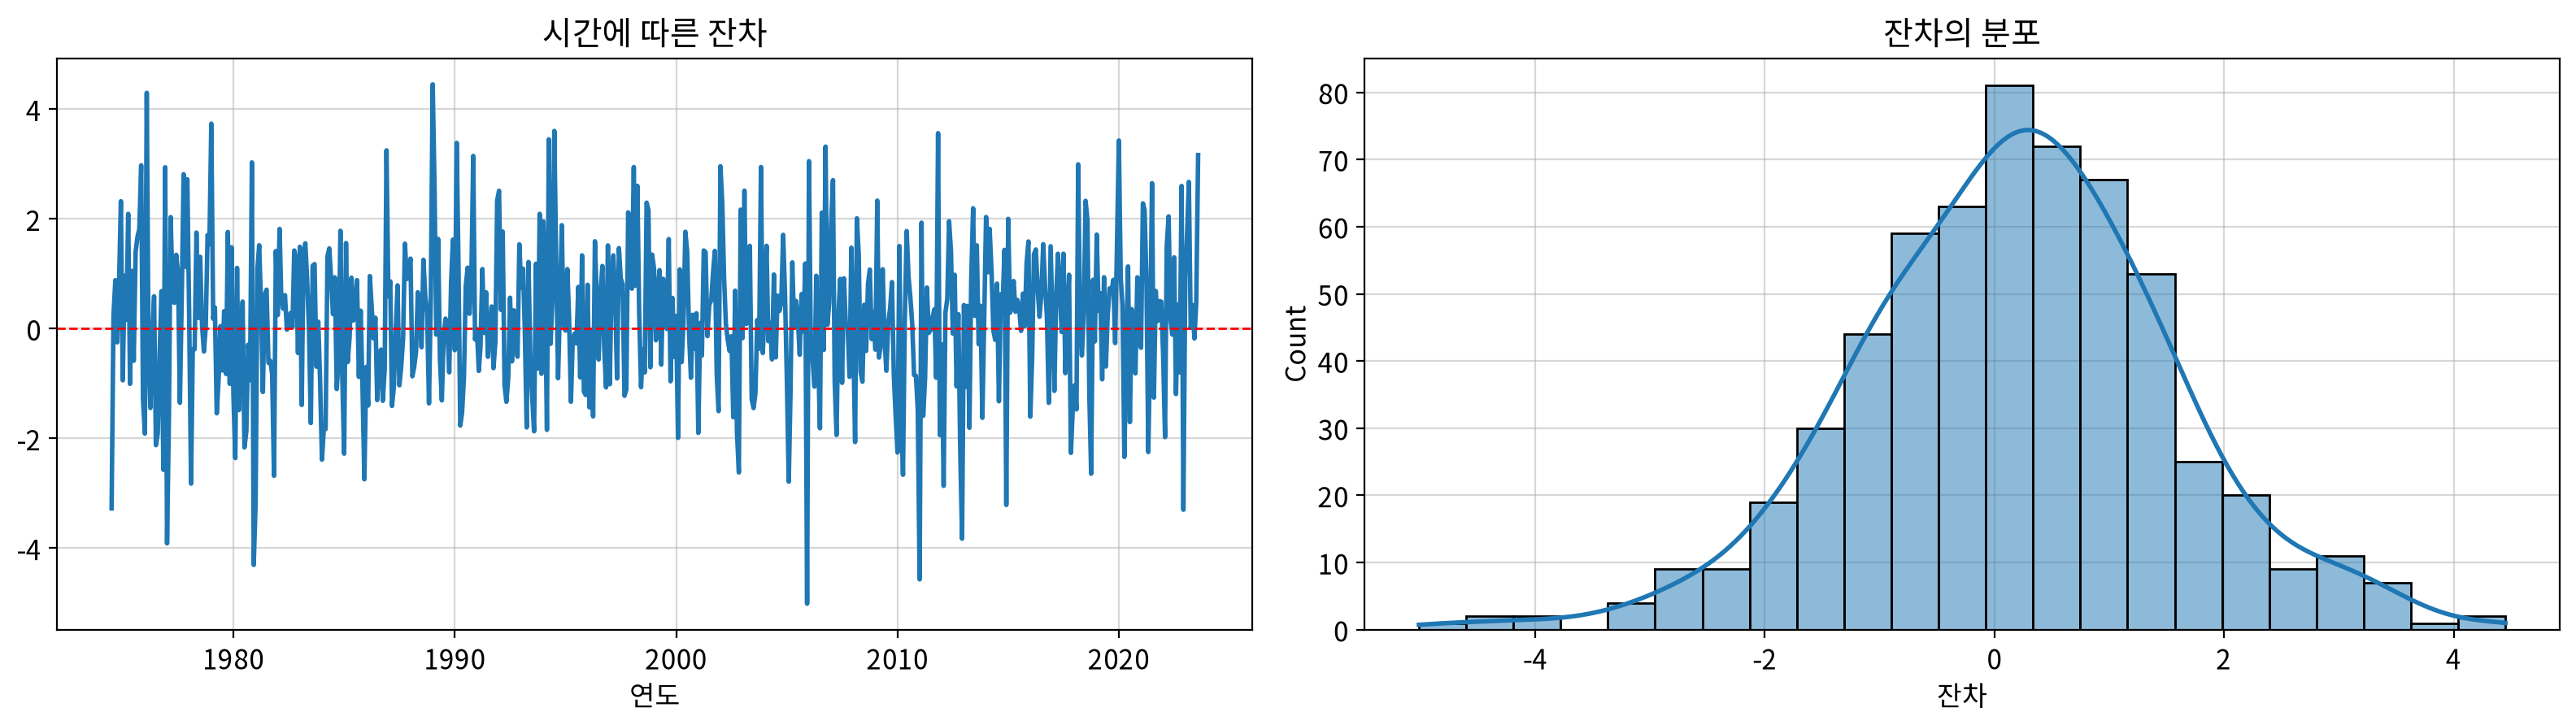

,가정,관측치 수,통계량,p-value,통과,판정,비고
검정,,,,,,,
Ljung-Box (시차 12),무상관,590,8.622,0.473,True,통과 (자기상관 없음),자유도 9
Ljung-Box (시차 24),무상관,590,23.863,0.300,True,통과 (자기상관 없음),자유도 21
Jarque-Bera,정규성,590,12.123,0.002,False,실패 (정규성 위배),왜도 -0.138 · 첨도 3.646
이분산(H),등분산성,590,0.966,0.810,True,통과 (등분산),뒤로 갈수록 작아짐


In [19]:
my_ts.report_residual(fit, xlabel="연도")

#### 적합도 평가

In [20]:
my_ts.report_score(fit, name="SARIMA 적합값")

평가 구간 590개 (1974-07-01 00:00:00 ~ 2023-08-01 00:00:00)
MAPE 68.021% → 43.064% | 기준선 대비 36.7% 개선


,관측치 수,MAE,RMSE,MAPE(%)
대상,,,,
SARIMA 적합값,590,1.075,1.383,43.064
계절 나이브 (시차 12),590,1.451,1.880,68.021


#### 오차 비율 뜯어보기

In [21]:
BURN = d + D * s                              # 차분이 소모하는 시점 수

actual = fit.model.data.orig_endog[BURN:]     # 관측값
fitted = fit.fittedvalues[BURN:]              # 적합값
ratio = (actual - fitted).abs() / actual.abs()

worst = ratio.idxmax()
print(f"오차 비율이 가장 큰 달: {worst:%Y-%m}")
print(f"  관측 {actual[worst]:.3f}℃ | 예측 {fitted[worst]:.3f}℃ "
      f"| 오차 {abs(actual[worst] - fitted[worst]):.3f}℃ | 오차 비율 {ratio[worst] * 100:.1f}%")

col = df["평균기온(℃)"]
print(f"평균기온이 -1℃ ~ 1℃ 사이인 달: {(col.abs() <= 1).sum()}개")

오차 비율이 가장 큰 달: 2006-01
  관측 -0.213℃ | 예측 -3.265℃ | 오차 3.052℃ | 오차 비율 1433.4%
평균기온이 -1℃ ~ 1℃ 사이인 달: 46개


### 문제 풀이

#### 1. 이 모형은 계절 차분을 한 번 거치기 때문에, 앞쪽 일부 구간에서는 잔차가 제대로 계산되지 않습니다. 이 구간을 제외하고 실제로 진단에 쓰이는 잔차는 몇 개인가요?

- **정답**: `590`
- **복습 개념**: 차분이 소모하는 시점(burn-in)을 잘라내는 절차입니다. 차분은 "이전 값과의 차"를 계산하는 것이므로, 뺄 대상이 없는 앞쪽 시점은 값이 생기지 않습니다. 모형이 아직 자리를 잡지 못한 이 구간의 잔차는 비정상적으로 커서 진단을 왜곡합니다.
- **풀이 접근**: 소모되는 시점 수는 `일반 차분 횟수 + 계절 차분 횟수 × 계절 주기` 로 계산합니다. 이 모형은 일반 차분을 하지 않고(0회) 계절 차분만 1회 하며 주기가 12개월이므로 12개 시점이 사라집니다. 전체 관측치에서 이만큼을 빼면 됩니다.
- **근거(계산 결과)**: 전체 관측치는 **602개**이고, 소모되는 시점은 0 + 1 × 12 = **12개**입니다. 따라서 진단 대상은 602 − 12 = **590개**입니다. 진단 결과표 위에 출력된 `진단 대상 590개 (앞 12개 제외)` 에서 확인됩니다.
- **자주 하는 실수**: 앞 단원(항공 승객 수)에서 13개를 잘랐던 것을 그대로 가져와 589라고 답하기 쉽습니다. 그때는 일반 차분을 1회 했기 때문에 1 + 1 × 12 = 13이었습니다. 잘라낼 개수는 데이터마다 정해진 값이 아니라 **그 모형의 차분 횟수에서 나온다**는 점을 기억하세요.

#### 2. 잔차에 시간적 패턴이 남았는지 여러 시차를 묶어 검정할 때, 시차 12에 대한 검정에서 사용된 자유도는 얼마인가요?

- **정답**: `9`
- **복습 개념**: 포트맨토 검정의 자유도 조정입니다. 잔차는 관측된 값이 아니라 **모형이 계수를 추정하고 남긴 값**이므로, 추정한 계수 수만큼 자유도를 깎아야 합니다.
- **풀이 접근**: 자유도는 `검정 시차 − 추정한 계수 수` 입니다. 추정한 계수 수는 차수 표기에서 AR·MA 자리를 모두 더한 값으로, 계절 부분까지 포함합니다. 여기서 차분 횟수는 계수가 아니므로 세지 않습니다.
- **근거(계산 결과)**: 이 모형은 비계절 AR 1개, 비계절 MA 1개, 계절 AR 0개, 계절 MA 1개로 **3개**의 계수를 추정했습니다. 따라서 자유도는 12 − 3 = **9**입니다. 진단 결과표의 `비고` 열에 `자유도 9` 로 표시되어 있습니다.
- **헷갈리기 쉬운 점**: 차분 횟수(0회·1회)까지 더해 12 − 4 = 8이라고 답하기 쉽습니다. 차분은 데이터를 변형하는 절차일 뿐 추정되는 계수가 아닙니다. 자유도를 깎지 않으면 유의확률이 실제보다 크게 나와 "문제 없음" 쪽으로 관대해집니다.

#### 3. 이 모형의 잔차가 만족해야 하는 세 가지 가정 가운데, 유의수준 5%에서 지켜지지 않은 가정은 무엇인가요?

- **정답**: `정규성`
- **복습 개념**: 잔차의 세 가정(무상관 · 정규성 · 등분산성) 판정입니다. 각 가정마다 검정이 하나씩 대응하며, 유의확률이 0.05보다 작으면 그 가정이 깨진 것입니다.
- **풀이 접근**: 진단 결과표에서 검정별 유의확률을 0.05와 비교합니다. 0.05보다 작은 줄이 통과하지 못한 가정입니다.
- **근거(계산 결과)**: 자기상관 검정은 0.473과 0.300, 등분산 검정은 0.810으로 모두 0.05보다 큽니다. 반면 왜도와 첨도를 묶어 정규분포 여부를 보는 검정은 **0.002**로 0.05보다 작습니다. 결과표에서도 이 줄만 `통과` 가 False이고, 표 위에 `실패한 검정: Jarque-Bera` 로 요약되어 있습니다.
- **함께 생각해 볼 점**: 왜도는 −0.138로 거의 대칭인데 첨도가 3.646으로 정규분포(3)보다 뾰족합니다. 즉 좌우로 치우친 것이 아니라 **평소보다 유난히 춥거나 더웠던 달이 몇 번 있었다**는 뜻입니다. 590개나 되는 큰 표본에서는 이런 작은 차이도 검정이 잡아냅니다. 이 경우 예측값 자체는 쓸 수 있지만, 예측구간의 폭은 그대로 믿기 어렵다는 점을 보고서에 밝혀야 합니다.

#### 4. 잔차의 흔들림이 앞 구간과 뒤 구간에서 일정한지는 두 구간의 분산비로 판정합니다. 이 분산비 값은 얼마인가요? (소수 셋째 자리)

- **정답**: `0.966`
- **복습 개념**: 등분산성 검정의 통계량 읽기입니다. 뒤 구간의 분산을 앞 구간의 분산으로 나눈 값이며, 1에 가까울수록 흔들림이 일정하다는 뜻입니다.
- **풀이 접근**: 진단 결과표에서 등분산 검정에 해당하는 줄의 통계량을 읽습니다. 값이 1보다 큰지 작은지로 흔들림이 커지는 방향인지 작아지는 방향인지도 함께 판단합니다.
- **근거(계산 결과)**: 분산비는 **0.966**으로 1에 거의 붙어 있고, 유의확률도 0.810으로 매우 큽니다. 50년 동안 기온의 **변동 폭 자체는 거의 그대로**라는 뜻입니다. 1보다 아주 조금 작으므로 방향은 `뒤로 갈수록 작아짐` 으로 표시됩니다.
- **실무 포인트**: 이 값이 1보다 크게 벗어나면 예측구간을 그대로 쓸 수 없습니다. 1보다 크면 뒤로 갈수록 더 크게 흔들린다는 뜻이라 예측구간이 **실제보다 좁게** 잡혀 위험하고, 1보다 작으면 **넓게** 잡혀 보수적입니다. 여기서는 0.966이라 어느 쪽으로도 걱정할 필요가 없습니다.

#### 5. 임원 보고에서 "이 모형은 평균적으로 몇 도쯤 빗나갑니다"라고 한마디로 말하려 합니다. 그 값은 얼마인가요? (소수 셋째 자리, 단위 ℃)

- **정답**: `1.075`
- **복습 개념**: MAE(평균절대오차)의 해석입니다. 오차의 절댓값을 그대로 평균 낸 값이라, 데이터와 **같은 단위로** 성능을 말할 수 있는 지표입니다.
- **풀이 접근**: 적합도 평가표에서 모형 행의 평균절대오차를 읽습니다. 함께 계산된 기준선(작년 같은 달의 기온을 그대로 쓰는 방식)의 값과 비교해 모형이 그보다 나은지도 확인합니다.
- **근거(계산 결과)**: 모형의 평균절대오차는 **1.075℃**입니다. 기준선은 1.451℃이므로 모형이 약 0.4℃만큼 더 정확합니다. 오차 제곱을 거쳐 계산하는 지표는 1.383℃로 조금 더 큰데, 이는 드물게 발생하는 큰 오차에 더 민감하기 때문입니다.
- **헷갈리기 쉬운 점**: 두 지표의 차이(1.075 vs 1.383)가 크지 않다는 것은 **유난히 크게 빗나간 달이 드물다**는 신호입니다. 만약 둘의 차이가 크게 벌어졌다면 평소에는 잘 맞다가 특정 달에만 크게 어긋난다는 뜻이므로, 그 달들을 따로 살펴봐야 합니다.

#### 6. 그런데 오차를 비율로 환산한 지표는 43%를 넘습니다. 평균 1℃ 남짓 빗나가는 모형인데도 이 값이 부풀려진 이유는 겨울철 관측값이 어떤 값에 가까워지기 때문인가요? (정수, 단위 ℃)

- **정답**: `0`
- **복습 개념**: MAPE(평균절대백분율오차)의 한계입니다. 오차를 관측값으로 나눠 비율을 만들기 때문에, **관측값이 0에 가까워지면 분모가 0으로 수렴해 비율이 폭발**합니다.
- **풀이 접근**: 오차 비율이 가장 큰 달을 찾아 그 달의 관측값과 오차를 함께 봅니다. 오차 자체는 작은데 비율만 터무니없이 큰 달이 있다면, 그 달의 관측값이 어떤 값 근처인지 확인하면 됩니다.
- **근거(계산 결과)**: 오차 비율이 가장 큰 달은 2006년 1월로, 관측 −0.213℃ · 예측 −3.265℃입니다. 오차는 3.052℃에 불과한데 관측값이 **0℃** 바로 옆이라 비율은 1433.4%가 됩니다. 서울의 월평균 기온이 −1℃ ~ 1℃ 사이인 달은 50년간 46개나 되므로, 이런 달들이 평균을 끌어올려 43%라는 숫자가 만들어집니다.
- **결론**: 비율 지표는 **0을 지나지 않는 데이터**(승객 수, 매출액, 판매량)에서만 쓸 수 있습니다. 기온처럼 영하와 영상을 오가는 값에는 쓰면 안 됩니다. 팀장에게 드릴 답은 이렇습니다 — 자기상관과 등분산 가정은 지켜졌고 성능은 **평균 1.075℃ 오차로 기준선보다 낫다**, 다만 정규성이 깨졌으니 **예측구간의 폭은 여유를 두고 해석**하겠다. 그리고 비율 지표 43%는 기온 데이터에서 의미가 없으므로 보고서에서 **뺀다.**